# Hemoflow Verification Document

This document outlines the process for verifying the HemoFlow C++ software package, which is based on the Palabos lattice–Boltzmann CFD solver framework. As the Palabos package is already well verified, our test cases focus only on the domain-specific features, such as the arbitrary parabolic inlet profile, Murray’s law-based outlet flow rates, and porous-layer stent modelling.

Three test cases were prepared:

- Straight pipe flow (Poiseuille flow) using our custom voxelisation process
- Realistic sidewall aneurysm from the Aneurisk database (https://ecm2.mathcs.emory.edu/aneuriskweb/about)
- Realistic sidewall aneurysm from the AneuX morphology database (https://github.com/hirsch-lab/aneuxdb)

Importing python packages for evaluation

In [51]:
import pandas as pd
import seaborn as sns

## Straight pipe flow (Poiseuille flow) 

As cerebral vessel sections can be represented as a branched system of curved pipes, our initial verification was performed on a straight pipe flow, commonly referred to as Poiseuille flow ([https://en.wikipedia.org/wiki/Hagen–Poiseuille_equation](https://en.wikipedia.org/wiki/Hagen%E2%80%93Poiseuille_equation)). This case provides an analytical solution for both the fully developed velocity profile and the pressure drop across a given section.

The following features were examined, and their outcomes are summarised below:

- Startup ramping process to eliminate transient effects from the initial condition
    - For a straight geometry, a pressure wave was observed, which required a long time to decay. When tested on a patient-specific case, these waves dissipated almost immediately due to the pronounced curvature of the vessel section.
- Time-dependent volume flow rate (VFR) condition read from a text file
    - The normalised VFR curve values are read from text files, and the parabolic velocity profile is scaled according to the prescribed boundary condition velocity magnitude and the normalised curve.
- Parabolic velocity boundary condition setup
    - The algorithm can impose velocity profiles in arbitrary directions and positions, which is crucial since outlets may lie near the corners of the computational domain. The boundary condition can also prescribe both inlet and outlet VFR values.
- Zero-pressure boundary condition
    - As noted previously, this condition does not dampen pressure waves.
- Porous layer resistance applied to stent voxels
    - Since this feature is central to our current application, we examined its dependency on voxel size as well as the influence of stent surface curvature.

### Voxel size dependence

#### Pressure drop

In [ ]:
pipe_dx=pd.read_csv('./input/dx_pipe_dp_sensitivity_output.csv')
pipe_dx.drop(index=pipe_dx.index[0], inplace=True)
pipe_dx.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
pipe_dx

,run_id,dx,u,l,q,dt,elem,save_dt,t_end,pressure_drop
1,1,0.30,0.5,0,0,0.00001,50000,1.0,2.5,90.671189
2,2,0.20,0.5,0,0,0.00001,50000,1.0,2.5,89.130026
3,3,0.15,0.5,0,0,0.00001,50000,1.0,2.5,86.024537
4,4,0.10,0.5,0,0,0.00001,50000,1.0,2.5,85.855040
5,5,0.08,0.5,0,0,0.00001,50000,1.0,2.5,86.737874


<Axes: xlabel='dx', ylabel='pressure_drop'>

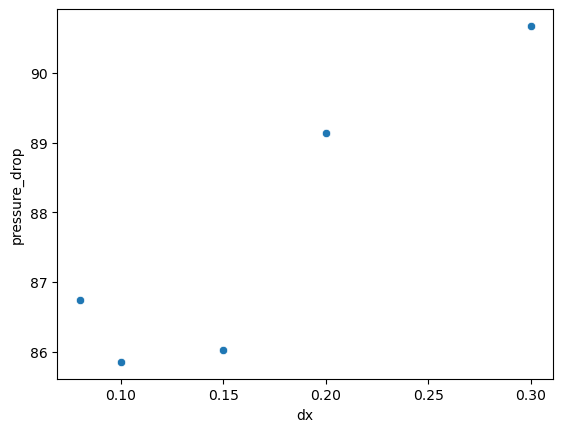

In [53]:
sns.scatterplot(pipe_dx, x='dx', y='pressure_drop')

#### Velocity profiles

Velocity profiles for coarse and fine voxel sizes

Coarse

![](input/profile_comp_coarse.png "coarse profile")

Fine

![](input/profile_comp_fine.png "fine profile")

#### Pressure drop with a straight flow diverter

TODO

#### Pressure drop with a curved flow diverter

TODO

## Aneurisk testcase

General description eqs etc

### Voxel size dependence

In [54]:
aneurisk_dx=pd.read_csv('./input/dx_aneurisk_sensitivity_output.csv')
aneurisk_dx.drop(index=aneurisk_dx.index[0], inplace=True)
aneurisk_dx.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
aneurisk_dx

,run_id,dx,u,l,q,dt,elem,save_dt,t_end,ane_0_velocity_vol_avg
1,1,0.20,0.5,0,0,0.00001,50000,0.016,0.8,0.068581
2,2,0.15,0.5,0,0,0.00001,50000,0.016,0.8,0.075535
3,3,0.10,0.5,0,0,0.00001,50000,0.016,0.8,0.079838
4,4,0.08,0.5,0,0,0.00001,50000,0.016,0.8,0.081336
5,5,0.06,0.5,0,0,0.00001,50000,0.016,0.8,0.081932
6,6,0.05,0.5,0,0,0.00001,50000,0.016,0.8,0.081930


<Axes: xlabel='dx', ylabel='ane_0_velocity_vol_avg'>

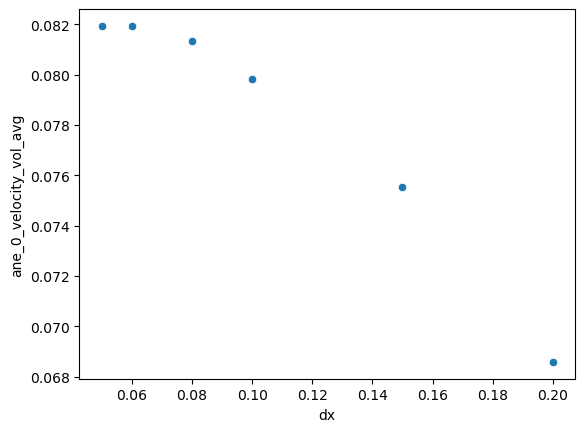

In [55]:
sns.scatterplot(aneurisk_dx, x='dx', y='ane_0_velocity_vol_avg')

### Timestep length dependency

In [ ]:
aneurisk_dt=pd.read_csv('./input/dt_aneurisk_sensitivity_output.csv')
aneurisk_dt.drop(index=aneurisk_dt.index[0], inplace=True)
aneurisk_dt.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
aneurisk_dt

,run_id,dt,u,l,q,dx,elem,save_dt,t_end,ane_0_velocity_vol_avg
1,1,0.000030,0.5,0,0,0.08,50000,0.016,0.8,0.080689
2,2,0.000020,0.5,0,0,0.08,50000,0.016,0.8,0.081357
3,3,0.000010,0.5,0,0,0.08,50000,0.016,0.8,0.081336
4,4,0.000009,0.5,0,0,0.08,50000,0.016,0.8,0.081889
5,5,0.000008,0.5,0,0,0.08,50000,0.016,0.8,0.081092


<Axes: xlabel='dt', ylabel='ane_0_velocity_vol_avg'>

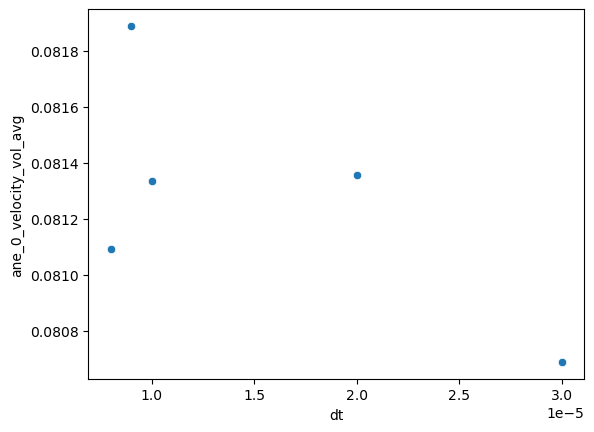

In [61]:
sns.scatterplot(aneurisk_dt, x='dt', y='ane_0_velocity_vol_avg')

### Save time dependency

In [64]:
aneurisk_save_dt=pd.read_csv('./input/save_dt_aneurisk_sensitivity_output.csv')
aneurisk_save_dt.drop(index=aneurisk_save_dt.index[0], inplace=True)
aneurisk_save_dt.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
aneurisk_save_dt

,run_id,save_dt,u,l,q,dt,dx,elem,t_end,ane_0_velocity_vol_avg
1,1,0.080000,0.5,0,0,0.00002,0.1,50000,0.8,0.078794
2,2,0.040000,0.5,0,0,0.00002,0.1,50000,0.8,0.078346
3,3,0.020000,0.5,0,0,0.00002,0.1,50000,0.8,0.080235
4,4,0.016000,0.5,0,0,0.00002,0.1,50000,0.8,0.080456
5,5,0.013333,0.5,0,0,0.00002,0.1,50000,0.8,0.081259
6,6,0.008000,0.5,0,0,0.00002,0.1,50000,0.8,0.080998
7,7,0.004000,0.5,0,0,0.00002,0.1,50000,0.8,0.081253
8,8,0.001600,0.5,0,0,0.00002,0.1,50000,0.8,0.081409


<Axes: xlabel='save_dt', ylabel='ane_0_velocity_vol_avg'>

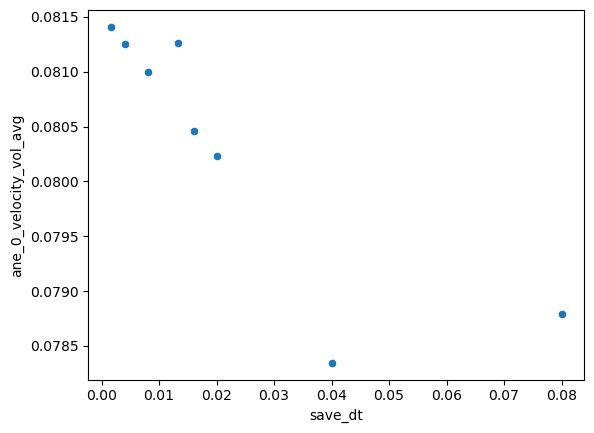

In [63]:
sns.scatterplot(aneurisk_save_dt, x='save_dt', y='ane_0_velocity_vol_avg')